In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [8]:
data = pd.read_csv('books_data.csv')
data.head(5)

,bookID,title,authors,average_rating
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78


In [10]:
data.columns

Index(['bookID', 'title', 'authors', 'average_rating'], dtype='object')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bookID          11127 non-null  int64 
 1   title           11127 non-null  object
 2   authors         11127 non-null  object
 3   average_rating  11127 non-null  object
dtypes: int64(1), object(3)
memory usage: 347.8+ KB


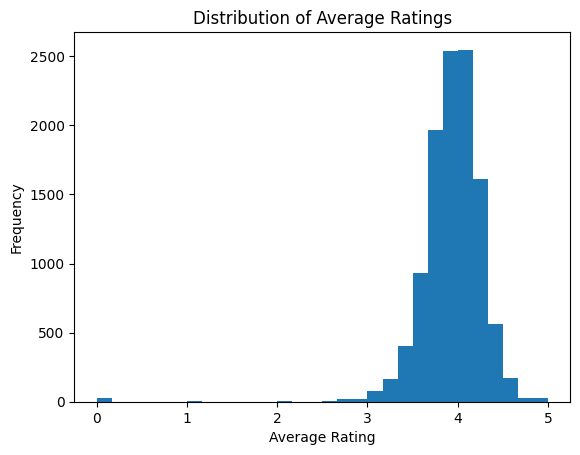

In [22]:
import matplotlib.pyplot as plt

# Convert to numeric (important)
data['average_rating'] = pd.to_numeric(data['average_rating'], errors='coerce')

# Remove null values
ratings = data['average_rating'].dropna()

# Plot
plt.hist(ratings, bins=30)

plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")

plt.show()

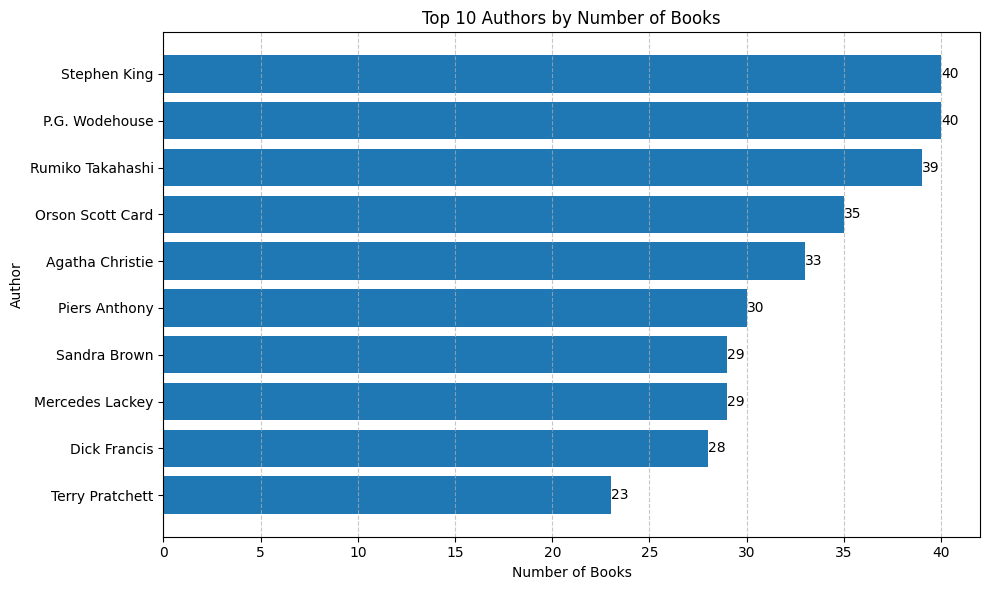

In [23]:

# Top 10 authors
top_authors = data['authors'].value_counts().head(10)

plt.figure(figsize=(10,6))

# Bar chart
bars = plt.barh(top_authors.index, top_authors.values)

# Add values on bars
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center')

# Labels & title
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.title("Top 10 Authors by Number of Books")

# Highest value on top
plt.gca().invert_yaxis()

# Grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# convert 'average_rating' to numeric data type
data['average_rating'] = pd.to_numeric(data['average_rating'],errors = 'coerce')

In [31]:
# create a new column 'book_content' by combining 'title', and 'authors'
data['book_content'] = data['title'] + ' ' + data['authors']
data.head()

,bookID,title,authors,average_rating,book_content
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,Harry Potter and the Half-Blood Prince (Harry ...
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,Harry Potter and the Order of the Phoenix (Har...
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,Harry Potter and the Chamber of Secrets (Harry...
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,Harry Potter and the Prisoner of Azkaban (Harr...
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,Harry Potter Boxed Set Books 1-5 (Harry Potte...


In [32]:
# Create the tf-idf matrix
tfidf = TfidfVectorizer(stop_words = 'english')
tfidf_matrix = tfidf.fit_transform(data['book_content'])

# Create a cosine similarity matrix
cosine_sim = linear_kernel(tfidf_matrix , tfidf_matrix)

In [43]:
def recommend_books(book_title, cosine_sim=cosine_sim):
    # Get the index of the book that matches the title
    idx = data[data['title'] == book_title].index[0]

    # Get the cosine similarity scores for all books with this book
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the books based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the top 10 most similar books (excluding the input book)
    sim_scores = sim_scores[1:11]

    # Get the book indices
    book_indices = [i[0] for i in sim_scores]

    # Return the top 10 recommended books
    return data['title'].iloc[book_indices]

In [44]:
book_title = "Seven Plays"
recommended_books = recommend_books(book_title)
print(recommended_books)

3322                               Buried Child
3559     See You Around  Sam! (Sam Krupnik  #3)
2871                Sam Walton: Made In America
4854    The Secret Seven (The Secret Seven  #1)
7768                               Seven Novels
7978                      The Atlantis Dialogue
2205                          Early Candlelight
449                       Medea and Other Plays
452                 The Bacchae and Other Plays
5850                                 Waterworks
Name: title, dtype: object
